# 03 — Conservative Pseudo-Labeling with LightGBM

This notebook extends the LightGBM baseline to the unlabeled HCP cohort in a conservative way.

Goals:
- start from the LightGBM supervised baseline
- score the unlabeled HCP population
- keep only high-confidence pseudo-label candidates
- apply class-specific confidence thresholds
- apply a class prior guard to avoid collapse into the majority class
- save candidate tables for review before any expanded retraining


In [36]:
from pathlib import Path
import json
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

warnings.filterwarnings('ignore')
pd.set_option('display.max_columns', 300)
pd.set_option('display.float_format', lambda x: f"{x:,.4f}")


## 1. Configuration

In [37]:
DATA_DIR = Path('data')
MODELING_DIR = DATA_DIR / 'modeling_lightgbm'
SSL_DIR = DATA_DIR / 'ssl_lightgbm'
FIG_DIR = SSL_DIR / 'figures'

SSL_DIR.mkdir(parents=True, exist_ok=True)
FIG_DIR.mkdir(parents=True, exist_ok=True)

FEATURE_MATRIX_PATH = MODELING_DIR / 'hcp_feature_matrix.parquet'
OOF_PATH = MODELING_DIR / 'lightgbm_oof_predictions.parquet'
SCALING_PATH = MODELING_DIR / 'lightgbm_class_scaling.json'
MODEL_PATH = MODELING_DIR / 'lightgbm_final_model.joblib'

TARGET_PRECISION = 0.95
MIN_MARGIN = 0.15
MAX_RELATIVE_EXPANSION_PER_CLASS = 0.75
MIN_CONFIDENCE_FALLBACK = 0.85

required_paths = [FEATURE_MATRIX_PATH, OOF_PATH, SCALING_PATH, MODEL_PATH]
for p in required_paths:
    if not p.exists():
        raise FileNotFoundError(f'Required asset not found: {p.resolve()}')


## 2. Load LightGBM baseline assets

In [38]:
hcp_feature_matrix = pd.read_parquet(FEATURE_MATRIX_PATH)
oof_df = pd.read_parquet(OOF_PATH)
with open(SCALING_PATH, 'r') as f:
    scaling_payload = json.load(f)
final_bundle = joblib.load(MODEL_PATH)

print('Feature matrix shape:', hcp_feature_matrix.shape)
print('Model in payload:', scaling_payload['model_name'])
print('Class order:', scaling_payload['class_order'])


Feature matrix shape: (20931, 716)
Model in payload: lightgbm_cost_sensitive
Class order: ['SEG_A', 'SEG_B', 'SEG_C']


## 3. Split labeled and unlabeled HCPs

In [39]:
feature_exclude = {'NUEVO_ID', 'ATSEG_HCP', 'IS_LABELED_HCP', 'HCP_FOLD'}
feature_cols = [c for c in hcp_feature_matrix.columns if c not in feature_exclude]

labeled_df = hcp_feature_matrix[hcp_feature_matrix['IS_LABELED_HCP'] == 1].copy()
unlabeled_df = hcp_feature_matrix[hcp_feature_matrix['IS_LABELED_HCP'] == 0].copy()

X_labeled = labeled_df[feature_cols].copy()
y_labeled = labeled_df['ATSEG_HCP'].copy()
X_unlabeled = unlabeled_df[feature_cols].copy()

label_encoder = final_bundle['label_encoder']
class_names = scaling_payload['class_order']
class_scaling = np.array([scaling_payload['class_scaling'][c] for c in class_names])

print('Labeled HCPs:', labeled_df.shape[0])
print('Unlabeled HCPs:', unlabeled_df.shape[0])


Labeled HCPs: 11899
Unlabeled HCPs: 9032


## 4. Derive class-specific confidence thresholds from OOF behavior

In [40]:
threshold_rows = []

for cls in class_names:
    tmp = oof_df[oof_df['pred_adj'] == cls].copy()
    if tmp.empty:
        threshold_rows.append({
            'class_name': cls,
            'chosen_threshold': MIN_CONFIDENCE_FALLBACK,
            'precision_at_threshold': np.nan,
            'support_selected': 0,
        })
        continue

    candidate_thresholds = np.round(np.arange(0.50, 0.991, 0.01), 2)
    chosen_threshold = None
    chosen_precision = None
    chosen_support = None

    for thr in candidate_thresholds:
        selected = tmp[tmp['confidence_adj'] >= thr]
        if selected.empty:
            continue
        precision_here = (selected['ATSEG_HCP'] == selected['pred_adj']).mean()
        if precision_here >= TARGET_PRECISION:
            chosen_threshold = thr
            chosen_precision = precision_here
            chosen_support = len(selected)
            break

    if chosen_threshold is None:
        chosen_threshold = max(MIN_CONFIDENCE_FALLBACK, float(tmp['confidence_adj'].quantile(0.90)))
        selected = tmp[tmp['confidence_adj'] >= chosen_threshold]
        chosen_precision = (selected['ATSEG_HCP'] == selected['pred_adj']).mean() if len(selected) else np.nan
        chosen_support = len(selected)

    threshold_rows.append({
        'class_name': cls,
        'chosen_threshold': chosen_threshold,
        'precision_at_threshold': chosen_precision,
        'support_selected': chosen_support,
    })

class_thresholds = pd.DataFrame(threshold_rows)
class_thresholds.to_csv(SSL_DIR / 'lightgbm_class_confidence_thresholds.csv', index=False)
class_thresholds


,class_name,chosen_threshold,precision_at_threshold,support_selected
0,SEG_A,0.9407,0.9127,687
1,SEG_B,0.9800,1.0000,8
2,SEG_C,0.9900,1.0000,1


## 5. Score the unlabeled HCP cohort with LightGBM

In [41]:
estimator = final_bundle['estimator']
raw_proba = estimator.predict_proba(X_unlabeled)
adj_proba = raw_proba * class_scaling.reshape(1, -1)
adj_proba = adj_proba / adj_proba.sum(axis=1, keepdims=True)

unlabeled_scores = unlabeled_df[['NUEVO_ID']].copy()
for i, cls in enumerate(class_names):
    unlabeled_scores[f'proba_raw__{cls}'] = raw_proba[:, i]
    unlabeled_scores[f'proba_adj__{cls}'] = adj_proba[:, i]

pred_idx = adj_proba.argmax(axis=1)
unlabeled_scores['predicted_class'] = [class_names[i] for i in pred_idx]
unlabeled_scores['confidence_adj'] = adj_proba.max(axis=1)
sorted_proba = np.sort(adj_proba, axis=1)
unlabeled_scores['margin_adj'] = sorted_proba[:, -1] - sorted_proba[:, -2]
unlabeled_scores.head()


,NUEVO_ID,proba_raw__SEG_A,proba_adj__SEG_A,proba_raw__SEG_B,proba_adj__SEG_B,proba_raw__SEG_C,proba_adj__SEG_C,predicted_class,confidence_adj,margin_adj
0,1,0.9217,0.9297,0.0680,0.0583,0.0103,0.0119,SEG_A,0.9297,0.8714
1,2,0.9618,0.9648,0.0295,0.0251,0.0087,0.0101,SEG_A,0.9648,0.9397
3,4,0.8910,0.8992,0.0847,0.0727,0.0243,0.0282,SEG_A,0.8992,0.8265
4,5,0.8478,0.8453,0.0661,0.0560,0.0861,0.0987,SEG_A,0.8453,0.7466
5,6,0.9651,0.9675,0.0257,0.0219,0.0092,0.0106,SEG_A,0.9675,0.9456


## 6. Conservative eligibility rules

In [42]:
threshold_map = dict(zip(class_thresholds['class_name'], class_thresholds['chosen_threshold']))

unlabeled_scores['class_threshold'] = unlabeled_scores['predicted_class'].map(threshold_map)
unlabeled_scores['eligible_by_confidence'] = unlabeled_scores['confidence_adj'] >= unlabeled_scores['class_threshold']
unlabeled_scores['eligible_by_margin'] = unlabeled_scores['margin_adj'] >= MIN_MARGIN
unlabeled_scores['pseudo_label_eligible'] = unlabeled_scores['eligible_by_confidence'] & unlabeled_scores['eligible_by_margin']

eligibility_summary = unlabeled_scores.groupby('predicted_class')['pseudo_label_eligible'].agg(['sum', 'mean']).reset_index()
eligibility_summary


,predicted_class,sum,mean
0,SEG_A,1972,0.2317
1,SEG_B,1,0.0021
2,SEG_C,0,0.0000


## 7. Class prior guard

In [43]:
labeled_counts = y_labeled.value_counts().sort_index()
max_candidates_per_class = (labeled_counts * MAX_RELATIVE_EXPANSION_PER_CLASS).astype(int).to_dict()

selected_frames = []
for cls in class_names:
    tmp = unlabeled_scores[(unlabeled_scores['predicted_class'] == cls) & (unlabeled_scores['pseudo_label_eligible'])].copy()
    tmp = tmp.sort_values(['confidence_adj', 'margin_adj'], ascending=[False, False])
    cap = max_candidates_per_class.get(cls, 0)
    selected_frames.append(tmp.head(cap))

pseudo_label_candidates = pd.concat(selected_frames, axis=0).reset_index(drop=True)
pseudo_label_candidates['pseudo_label'] = pseudo_label_candidates['predicted_class']

unlabeled_scores.to_parquet(SSL_DIR / 'lightgbm_unlabeled_scored_all.parquet', index=False)
pseudo_label_candidates.to_parquet(SSL_DIR / 'lightgbm_pseudo_label_candidates.parquet', index=False)

summary = pd.DataFrame({
    'labeled_count': labeled_counts,
    'max_pseudo_label_cap': pd.Series(max_candidates_per_class),
    'selected_candidates': pseudo_label_candidates['pseudo_label'].value_counts().reindex(class_names).fillna(0).astype(int),
}).reset_index().rename(columns={'index': 'class_name'})
summary


,class_name,labeled_count,max_pseudo_label_cap,selected_candidates
0,SEG_A,6406,4804,1972
1,SEG_B,3349,2511,1
2,SEG_C,2144,1608,0


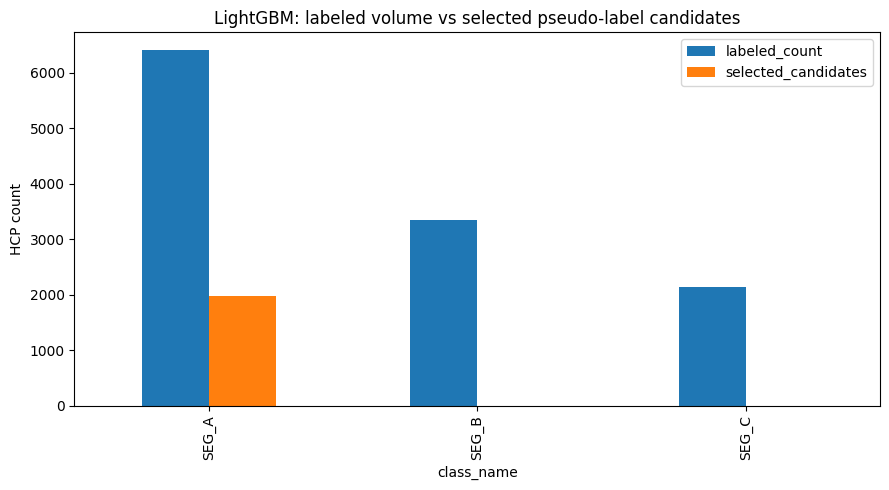

In [44]:
ax = summary.set_index('class_name')[['labeled_count', 'selected_candidates']].plot(
    kind='bar', figsize=(9, 5), title='LightGBM: labeled volume vs selected pseudo-label candidates'
)
ax.set_xlabel('class_name')
ax.set_ylabel('HCP count')
plt.tight_layout()
plt.savefig(FIG_DIR / 'lightgbm_pseudo_label_class_counts.png', dpi=150)
plt.show()


## 8. Review the highest-confidence candidates

In [45]:
pseudo_label_candidates.sort_values(['confidence_adj', 'margin_adj'], ascending=[False, False]).head(25)


,NUEVO_ID,proba_raw__SEG_A,proba_adj__SEG_A,proba_raw__SEG_B,proba_adj__SEG_B,proba_raw__SEG_C,proba_adj__SEG_C,predicted_class,confidence_adj,margin_adj,class_threshold,eligible_by_confidence,eligible_by_margin,pseudo_label_eligible,pseudo_label
0,17423,0.9907,0.9912,0.0060,0.0051,0.0032,0.0037,SEG_A,0.9912,0.9860,0.9407,True,True,True,SEG_A
1,18918,0.9906,0.9911,0.0067,0.0057,0.0028,0.0032,SEG_A,0.9911,0.9855,0.9407,True,True,True,SEG_A
2,20048,0.9901,0.9911,0.0082,0.0070,0.0017,0.0020,SEG_A,0.9911,0.9841,0.9407,True,True,True,SEG_A
3,13972,0.9910,0.9910,0.0043,0.0036,0.0047,0.0054,SEG_A,0.9910,0.9856,0.9407,True,True,True,SEG_A
4,17765,0.9902,0.9906,0.0063,0.0054,0.0035,0.0040,SEG_A,0.9906,0.9853,0.9407,True,True,True,SEG_A
5,17979,0.9892,0.9903,0.0089,0.0076,0.0018,0.0021,SEG_A,0.9903,0.9827,0.9407,True,True,True,SEG_A
6,17525,0.9892,0.9897,0.0071,0.0060,0.0037,0.0043,SEG_A,0.9897,0.9836,0.9407,True,True,True,SEG_A
7,17980,0.9881,0.9889,0.0085,0.0072,0.0034,0.0039,SEG_A,0.9889,0.9817,0.9407,True,True,True,SEG_A
8,19692,0.9871,0.9887,0.0122,0.0104,0.0008,0.0009,SEG_A,0.9887,0.9784,0.9407,True,True,True,SEG_A
9,19640,0.9875,0.9883,0.0091,0.0077,0.0035,0.0040,SEG_A,0.9883,0.9806,0.9407,True,True,True,SEG_A


## 9. Presentation summary

In [46]:
presentation_summary = {
    'model_used_for_ssl': 'LightGBM only',
    'target_precision_for_thresholds': TARGET_PRECISION,
    'minimum_margin': MIN_MARGIN,
    'max_relative_expansion_per_class': MAX_RELATIVE_EXPANSION_PER_CLASS,
    'thresholds': class_thresholds.set_index('class_name')['chosen_threshold'].to_dict(),
    'selected_candidates_by_class': summary.set_index('class_name')['selected_candidates'].to_dict(),
}
presentation_summary


{'model_used_for_ssl': 'LightGBM only',
 'target_precision_for_thresholds': 0.95,
 'minimum_margin': 0.15,
 'max_relative_expansion_per_class': 0.75,
 'thresholds': {'SEG_A': 0.9407229290176317, 'SEG_B': 0.98, 'SEG_C': 0.99},
 'selected_candidates_by_class': {'SEG_A': 1972, 'SEG_B': 1, 'SEG_C': 0}}